In [1]:
import numpy as np
from pathlib import Path
import reciprocalspaceship as rs
from meteor import rsmap
import gemmi
from meteor.sfcalc import gemmi_structure_to_calculated_map

from configuration import load_homepath

%load_ext autoreload
%autoreload 2

In [2]:

folderloc = load_homepath() + "meteor/test/data/"
dataloc_dark = folderloc + "scaled-test-data.mtz"
dataloc_dark = folderloc + "scaled-test-data.mtz"
ds = rs.read_mtz(dataloc_dark)
[col for col in ds.columns if "free" in col.lower()]

[]

In [3]:
from create_noisy_synth_data import pdb2noisy

In [8]:
synthloc = load_homepath() + "synthetic_cistrans/"
pdbloc_dark = synthloc + "trans.pdb"
pdbloc_light = synthloc + "100ps.pdb"
snr_factor = 15  # SNR at 2 Angstrom

save2file = True
noise_type = "gaussian"
noise_type = "poisson"
noise_type = "gaussian_flat"
pdb2noisy(
    pdbloc_dark,
    noise_type,
    high_resolution_limit=1.6,
    snr_factor=snr_factor,
    save2file=save2file,
)
pdb2noisy(
    pdbloc_light,
    noise_type,
    high_resolution_limit=1.6,
    snr_factor=snr_factor,
    save2file=save2file,
)

saved to  /Users/sbielfel/Nextcloud2/time_resolved/synthetic_cistrans/trans_gaussian_flat_15_dmin_16.mtz
saved to  /Users/sbielfel/Nextcloud2/time_resolved/synthetic_cistrans/100ps_gaussian_flat_15_dmin_16.mtz


In [6]:
high_resolution_limit = 1.5
struc_dark = gemmi.read_pdb(pdbloc_dark)
map_dark = gemmi_structure_to_calculated_map(
    struc_dark, high_resolution_limit=high_resolution_limit
)
map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)

struc_light = gemmi.read_pdb(pdbloc_light)
map_light = gemmi_structure_to_calculated_map(
    struc_light, high_resolution_limit=high_resolution_limit
)
map_light_np = map_light.to_3d_numpy_map(map_sampling=3)


In [7]:
file_loc = synthloc + "trans_noise3.mtz"
ds = rs.read_mtz(file_loc)
(ds.dtypes)

F_k           SFAmplitude
SIGF_k             Stddev
PHI_k               Phase
FreeR_flag         MTZInt
SIGFC              Stddev
dtype: object

H   K  L
0   0  0          inf
       2    36.014999
       4      18.0075
       6       12.005
       8      9.00375
              ...    
34  7  2     1.506135
       3     1.504491
       4     1.502199
    8  0     1.501003
       1     1.500678
Length: 38457, dtype: MTZReal


Text(0.5, 1.0, 'Noisy vs Clean data F')

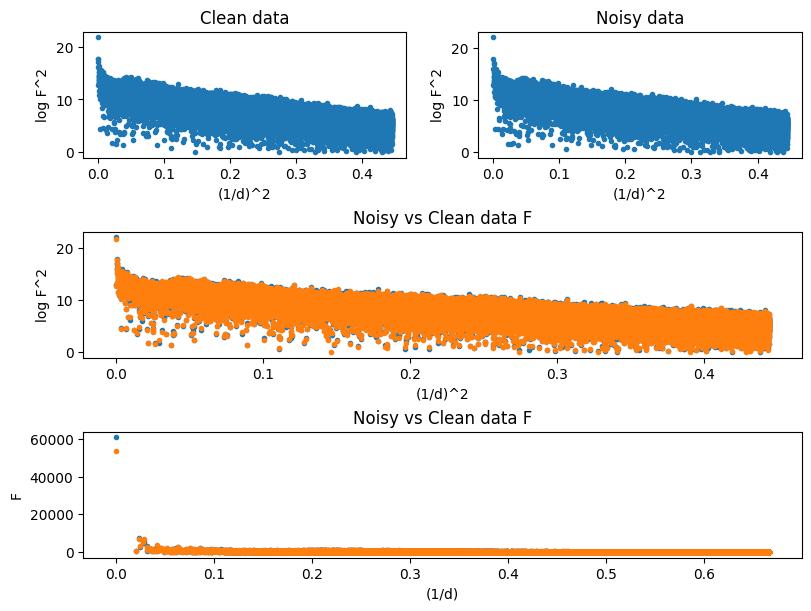

In [39]:
import matplotlib.pyplot as plt
from create_noisy_synth_data import make_clean_synthetic_data
diff_clean, map_dark_clean, _ = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    high_resolution_limit=1.5,
    dark_phases=False,
    snr_factor=0,
)
map_dark_clean= map_dark_clean[map_dark_clean["F"]>1]
options = dict(
        high_resolution_limit=1.5,
        dark_phases=True,
        snr_factor=10,
        noise_type="gaussian",
)
diffmap, map_dark, _ = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    **options
)
dhkl = map_dark.compute_dHKL()
dhkl_clean = map_dark_clean.compute_dHKL()
print(dhkl)
fig = plt.figure(constrained_layout=True, figsize=(8, 6))
from matplotlib.gridspec import GridSpec
gs = GridSpec(3, 2, figure=fig)
axs0 = fig.add_subplot(gs[0, 1])
axs1 = fig.add_subplot(gs[0, 0])
axs2 = fig.add_subplot(gs[2, :])
axs3 = fig.add_subplot(gs[1, :])
axs0.plot(1/dhkl**2, np.log(map_dark["F"]**2), ".")
axs1.plot(1/dhkl_clean**2, np.log(map_dark_clean["F"]**2), ".")
axs3.plot(1/dhkl**2, np.log(map_dark["F"]**2), ".")
axs3.plot(1/dhkl_clean**2, np.log(map_dark_clean["F"]**2), ".")
axs2.plot(1/dhkl, (map_dark["F"]), ".")
axs2.plot(1/dhkl_clean, (map_dark_clean["F"]), ".")

# bins = np.arange(1, 40, .1) 
# import pandas as pd
# average_clean = map_dark_clean.groupby(pd.cut(dhkl_clean, bins))['F'].mean()
# average = map_dark.groupby(pd.cut(dhkl, bins))['F'].mean()
# axs4 = fig.add_subplot(gs[3, :])
# axs4.plot(average.index.categories.mid, average, ".",label="Noisy data")
# axs4.plot(average_clean.index.categories.mid, average_clean, ".",label="Clean data")
# axs4.set_ylabel("F")
# axs4.set_xlabel("resolution")
# axs4.legend()

axs1.set_title("Clean data")
axs0.set_title("Noisy data")
axs0.set_ylabel("log F^2")
axs3.set_ylabel("log F^2")
axs1.set_ylabel("log F^2")
axs2.set_ylabel("F")
axs3.set_xlabel("(1/d)^2")
axs1.set_xlabel("(1/d)^2")
axs0.set_xlabel("(1/d)^2")
axs2.set_xlabel("(1/d)")
axs2.set_title("Noisy vs Clean data F")
axs3.set_title("Noisy vs Clean data F")

In [73]:
import matplotlib.pyplot as plt
from create_noisy_synth_data import make_clean_synthetic_data

list_of_dicts = []
diff_clean, map_dark_clean = make_clean_synthetic_data(
    pdbloc_dark,
    pdbloc_light,
    high_resolution_limit=1.5,
    dark_phases=False,
    snr_factor=0,
)

options = dict(
        high_resolution_limit=1.5,
        dark_phases=True,
        snr_factor=35,
        noise_type="gaussian",
)
for _ in range(16):
    diffmap, map_dark = make_clean_synthetic_data(
        pdbloc_dark,
        pdbloc_light,
        **options
    )
    # diffmap.drop((0, 0, 0), inplace=True)
    # print(map_dark)
    # print(map_dark_clean)
    map_dark.loc[(0, 0, 0), "F"] = map_dark_clean.loc[(0, 0, 0), "F"]

    map_dark_np = map_dark.to_3d_numpy_map(map_sampling=3)
    diffmap_np = diffmap.to_3d_numpy_map(map_sampling=3)
    pseudo_occupancy = -diffmap_np / map_dark_np

    list_of_dicts.append(
        {
            "diffmap": diffmap,
            "map_dark": map_dark,
            "map_dark_np": map_dark_np,
            "diffmap_np": diffmap_np,
            "pseudo_occupancy": pseudo_occupancy,
        }
    )

/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_52674/1093883791.py:32: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_52674/1093883791.py:32: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np
/var/folders/pr/w1s1g8813qn100g39nl2z99m0000gp/T/ipykernel_52674/1093883791.py:32: RuntimeWarning: divide by zero encountered in divide
  pseudo_occupancy = -diffmap_np / map_dark_np


In [74]:
diff_clean_np = diff_clean.to_3d_numpy_map(map_sampling=3)
clean_mask = np.abs(diff_clean_np) >0.2
default_mean = np.mean(diff_clean_np[clean_mask])


0 0.011510411
1 -0.0055720396
2 0.012378901
3 -0.022029381
4 -0.0063485173
5 -0.005312186
6 -0.0009920743
7 -0.011909468
8 -0.007275348
9 -0.004619167
10 0.005414631
11 0.019732846
12 -0.010223238
13 -0.026547609
14 0.0016139598
15 -0.0021638193


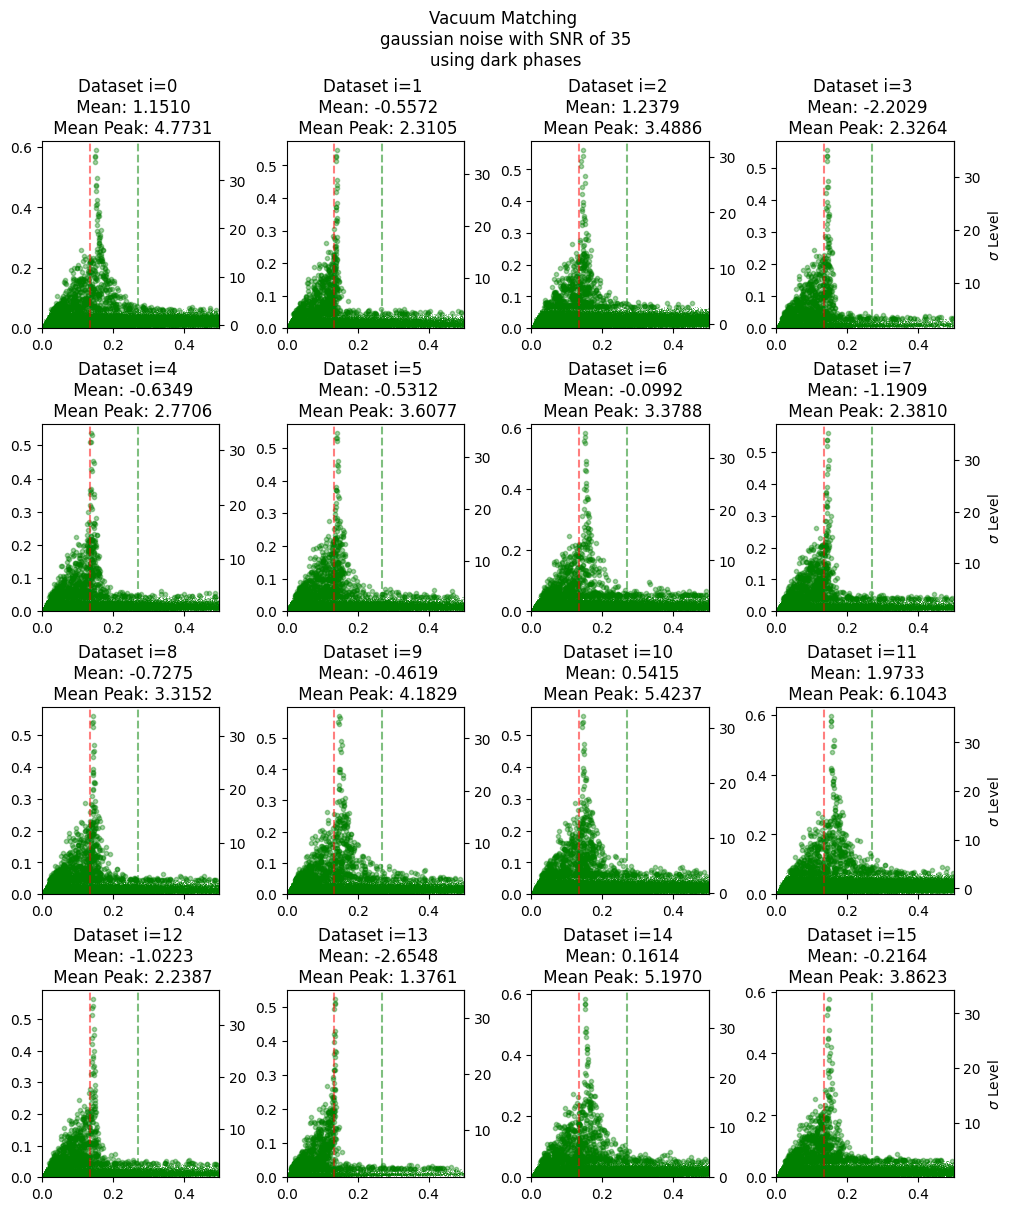

In [75]:
xmin = 0
ymin = 0
xmax = 0.5

fig, axs = plt.subplots(4,4, figsize=(10,12), constrained_layout = True)
for i, (dl, ax) in enumerate(zip(list_of_dicts, axs.flat)):
    pseudo = dl['pseudo_occupancy']
    diff = -dl['diffmap_np']
    
    
    # 2. Calculate stats LOCALLY for this specific subplot
    current_mean = np.mean(diff)
    current_std = np.std(diff)
    current_mean_peak = np.mean(diff[clean_mask]) - default_mean
    print(i, current_mean)
    
    # 3. Define the transformation functions with local closure
    # We use default arguments to "snap" the current mean/std into the function
    def abs_to_std(y, m=current_mean, s=current_std):
        return (y - m) / s

    def std_to_abs(z, m=current_mean, s=current_std):
        return (z * s) + m
    sig3 = std_to_abs(3)
    mask = np.logical_and.reduce([diff > ymin, pseudo > xmin, pseudo < xmax])
    mask_main = np.logical_and(mask, diff<sig3)
    mask_outlier = np.logical_and(mask, diff>=sig3)
    
    # 1. Plot the data
    ax.plot(pseudo[mask_outlier], diff[mask_outlier], '.', color='green', alpha=0.1)
    ax.plot(pseudo[mask_main], diff[mask_main], ',', color='green', alpha=0.1)


    # 4. Vertical lines and limits
    ax.axvline(0.135, color='red', linestyle='--', alpha=0.5)
    ax.axvline(0.27, color='green', linestyle='--', alpha=0.5)
    ax.set_ylim(0, None)
    ax.set_xlim(xmin, xmax)
    ax.set_title(f"Dataset i={i} \n Mean: {current_mean*100:.4f}\n Mean Peak: {current_mean_peak*100:.4f}")
    secax = ax.secondary_yaxis('right', functions=(abs_to_std, std_to_abs))
    if (i + 1) % 4 == 0: 
        secax.set_ylabel(r"$\sigma$ Level", fontsize=10)
    # secax.set_ylabel(r"Standard Deviations ($\sigma$)")

title = f"Vacuum Matching \n{options['noise_type']} noise with SNR of {options["snr_factor"]}\n"
title += f"using {'dark' if options['dark_phases'] else 'true'} phases"
_ =fig.suptitle(title)

In [87]:
diff_deviant = list_of_dicts[10]['diffmap']
print(diff_deviant)
diff_close = list_of_dicts[8]['diffmap']

                F         PHI
H  K L                       
0  0 1        NaN  300.587524
     2  15.749023         0.0
     3        NaN  330.777985
     4 -37.891525  180.000015
     5        NaN   28.810629
...           ...         ...
34 7 2        NaN  121.900787
     3        NaN     0.04032
     4        NaN    0.414682
   8 0        NaN     0.00003
     1        NaN  101.837654

[38599 rows x 2 columns]


In [ ]:
diff_deviant[diff_deviant.compute_dHKL()>20].head(20)
diff_deviant[np.abs(diff_deviant["F"])>500]

F         PHI
H  K  L                         
0  0  2   799.627576         0.0
   1  3   246.798977       270.0
   2  1   562.181201    0.000003
      2   687.176435  180.000015
      11  209.441193  180.000015
...              ...         ...
11 11 7   218.207395  226.796234
      16  250.788325   39.206161
13 1  8   226.976911  136.006897
15 7  14  236.423323  220.640518
16 5  3   230.492811  345.812683

[71 rows x 2 columns]

In [ ]:
diff_close[diff_close.compute_dHKL()>20].head(20)
diff_close[np.abs(diff_close["F"])>500]

F         PHI
H K  L                         
0 0  2   911.098128         0.0
  4  0  -536.625203         0.0
1 0  1  -725.881006        90.0
     3  -650.915108       270.0
  4  0  -535.746338       270.0
2 2  4    528.74675   96.799515
3 11 14 -500.155448  280.986542
6 2  15 -581.007116  263.801239

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

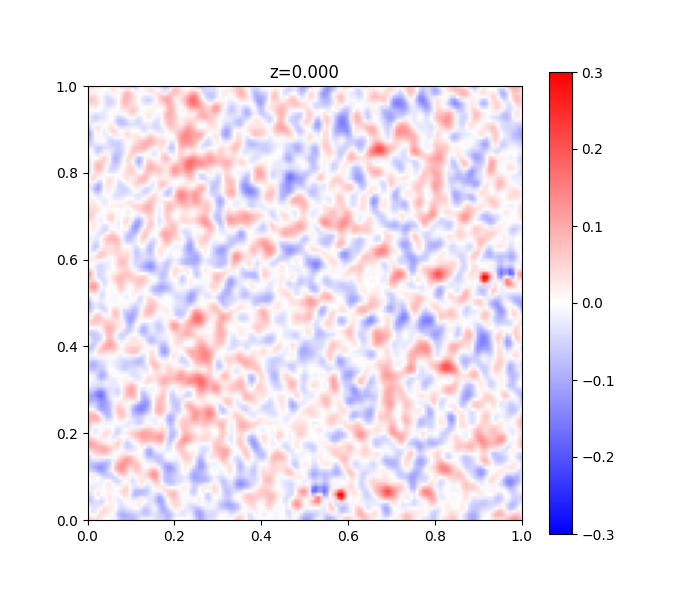

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

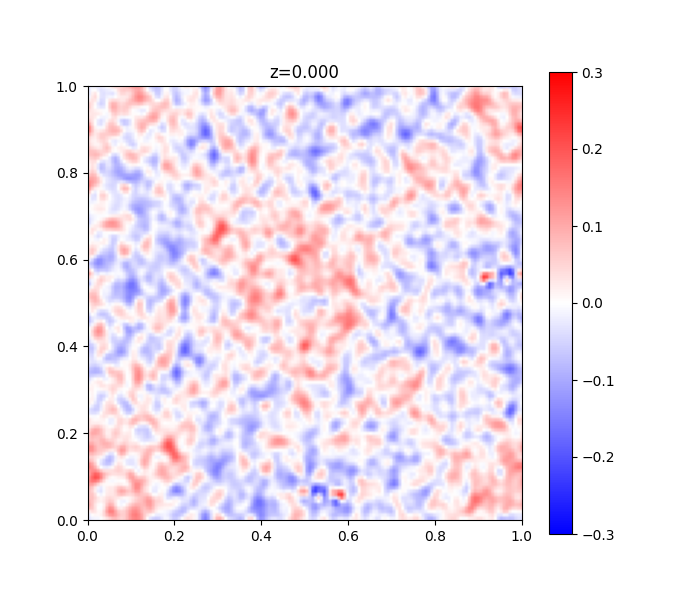

In [11]:
%matplotlib widget
from plotting3d import slice_3d
imkwargs=dict(vmin = -0.3, vmax=0.3, cmap='bwr')
_ = slice_3d(diff_close.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)
plt.show()
_ = slice_3d(diff_deviant.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)

interactive(children=(IntSlider(value=0, description='f0', max=107), Output()), _dom_classes=('widget-interact…

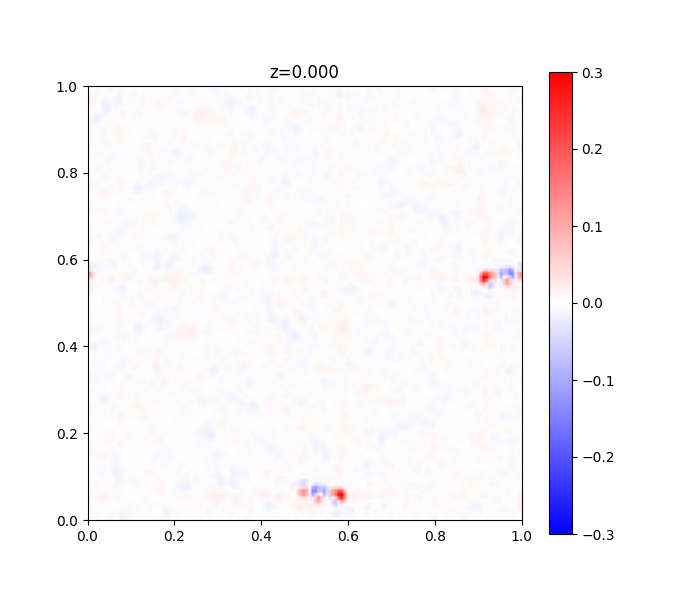

In [17]:
_ =slice_3d(diff_clean.to_3d_numpy_map(map_sampling=3), imkwargs=imkwargs)

In [ ]:
deviant_dict = list_of_dicts[4]
map_dark_dev = deviant_dict['map_dark_np'] 
diffmap_dev = deviant_dict['diffmap_np'] 

In [56]:
occus = [0.08, .135, .17, 0.2, .24, .4, .8, 5]
from skimage.feature import match_template 
p_devs = []
p_darks = []
mask = np.abs((map_light_np - map_dark_np))>0.2
for occu in occus:
    map_xtr_believe = map_dark_dev + 1/occu * diffmap_dev
    p_dev = match_template(map_xtr_believe, map_light_np)
    p_dark = match_template(map_xtr_believe, map_dark_np)
    p_devs.append(p_dev[0][0][0])
    p_darks.append(p_dark[0][0][0])
